In [1]:
import os

REPO_URL = "https://github.com/Raghavtripathii/docshield-ai.git"
REPO_DIR = "/content/docshield-ai"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}

%cd /content/docshield-ai

!git log -1 --oneline

Cloning into 'docshield-ai'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 57 (delta 20), reused 45 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 148.32 KiB | 16.48 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/docshield-ai
53fc71b (HEAD -> main, origin/main, origin/HEAD) chore: validate cloud ML execution environment


In [2]:
!python -m pip install --quiet -r requirements-dev.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 119.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.5 MB/s eta 0:00:00


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from collections import Counter

from src.config import CONFIG
from src.data import load_funsd
from src.labels import build_label_maps, get_label_list
from src.reproducibility import set_seed
from src.statistics import document_statistics, label_distribution

set_seed(CONFIG.seed)

print("Seed:", CONFIG.seed)
print("EDA environment ready.")

Seed: 42
EDA environment ready.


In [4]:
dataset = load_funsd()

print(dataset)
print()
print("Train documents:", len(dataset["train"]))
print("Test documents:", len(dataset["test"]))

README.md:   0%|          | 0.00/755 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 12.3MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 4.38MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/149 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'words', 'bboxes', 'ner_tags', 'image'],
        num_rows: 149
    })
    test: Dataset({
        features: ['id', 'words', 'bboxes', 'ner_tags', 'image'],
        num_rows: 50
    })
})

Train documents: 149
Test documents: 50


In [5]:
print("TRAIN FEATURES")
print(dataset["train"].features)

example = dataset["train"][0]

print("\nEXAMPLE FIELDS")
for key in example.keys():
    value = example[key]

    if key == "image":
        print(f"{key}: {value.size}")
    elif hasattr(value, "__len__"):
        print(f"{key}: {type(value).__name__}, length={len(value)}")
    else:
        print(f"{key}: {value}")

TRAIN FEATURES
{'id': Value('string'), 'words': List(Value('string')), 'bboxes': List(List(Value('int64'))), 'ner_tags': List(ClassLabel(names=['O', 'B-HEADER', 'I-HEADER', 'B-QUESTION', 'I-QUESTION', 'B-ANSWER', 'I-ANSWER'])), 'image': Image(mode=None, decode=True)}

EXAMPLE FIELDS
id: str, length=1
words: list, length=145
bboxes: list, length=145
ner_tags: list, length=145
image: (762, 1000)


In [6]:
label_list = get_label_list(dataset)
id2label, label2id = build_label_maps(label_list)

print("Number of labels:", len(label_list))

for idx, label in id2label.items():
    print(f"{idx}: {label}")

Number of labels: 7
0: O
1: B-HEADER
2: I-HEADER
3: B-QUESTION
4: I-QUESTION
5: B-ANSWER
6: I-ANSWER


In [7]:
stats = document_statistics(dataset)

display(stats.head())

print("\nShape:", stats.shape)

display(
    stats.groupby("split")["word_count"]
    .describe()
    .round(2)
)

,split,document_id,word_count,image_width,image_height
0,train,0,145,762,1000
1,train,1,232,762,1000
2,train,2,132,762,1000
3,train,3,295,762,1000
4,train,4,90,771,1000



Shape: (199, 5)


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,50.0,174.14,90.04,25.0,100.5,177.0,213.0,433.0
train,149.0,146.90,61.80,34.0,99.0,139.0,189.0,325.0


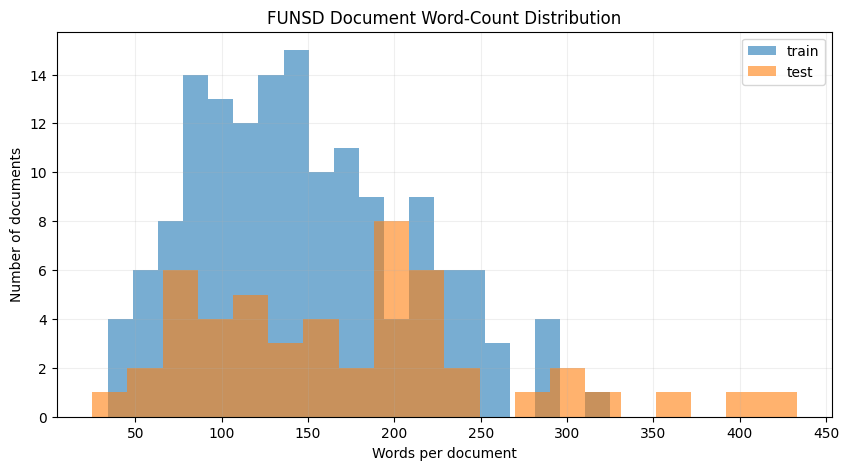

In [8]:
plt.figure(figsize=(10, 5))

for split in stats["split"].unique():
    values = stats.loc[
        stats["split"] == split,
        "word_count"
    ]

    plt.hist(
        values,
        bins=20,
        alpha=0.6,
        label=split,
    )

plt.xlabel("Words per document")
plt.ylabel("Number of documents")
plt.title("FUNSD Document Word-Count Distribution")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [9]:
train_distribution = label_distribution(
    dataset,
    "train",
)

test_distribution = label_distribution(
    dataset,
    "test",
)

distribution_df = pd.DataFrame({
    "train": pd.Series(train_distribution),
    "test": pd.Series(test_distribution),
}).fillna(0).astype(int)

display(distribution_df)

,train,test
0,3632,2385
1,441,119
2,1035,255
3,3253,1070
4,4008,1584
5,2732,809
6,6787,2485


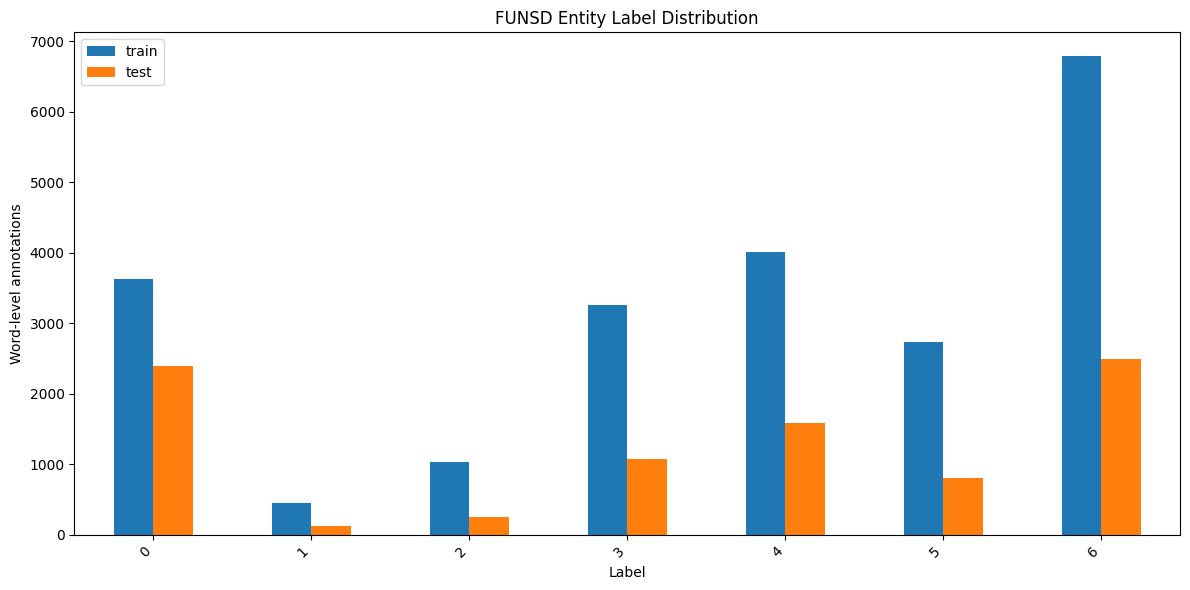

In [10]:
ax = distribution_df.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.set_title("FUNSD Entity Label Distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Word-level annotations")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [11]:
train_total = distribution_df["train"].sum()

imbalance_df = distribution_df.copy()

imbalance_df["train_percentage"] = (
    imbalance_df["train"] / train_total * 100
)

imbalance_df = imbalance_df.sort_values(
    "train_percentage",
    ascending=False,
)

display(imbalance_df)

print(
    "Largest training class:",
    imbalance_df.index[0],
)

print(
    "Largest-class percentage:",
    round(imbalance_df.iloc[0]["train_percentage"], 2),
    "%",
)

,train,test,train_percentage
6,6787,2485,31.007858
4,4008,1584,18.311404
0,3632,2385,16.593567
3,3253,1070,14.862025
5,2732,809,12.481725
2,1035,255,4.728618
1,441,119,2.014803


Largest training class: 6
Largest-class percentage: 31.01 %


Document ID: 0
Image size: (762, 1000)
Words: 145
Boxes: 145
Labels: 145


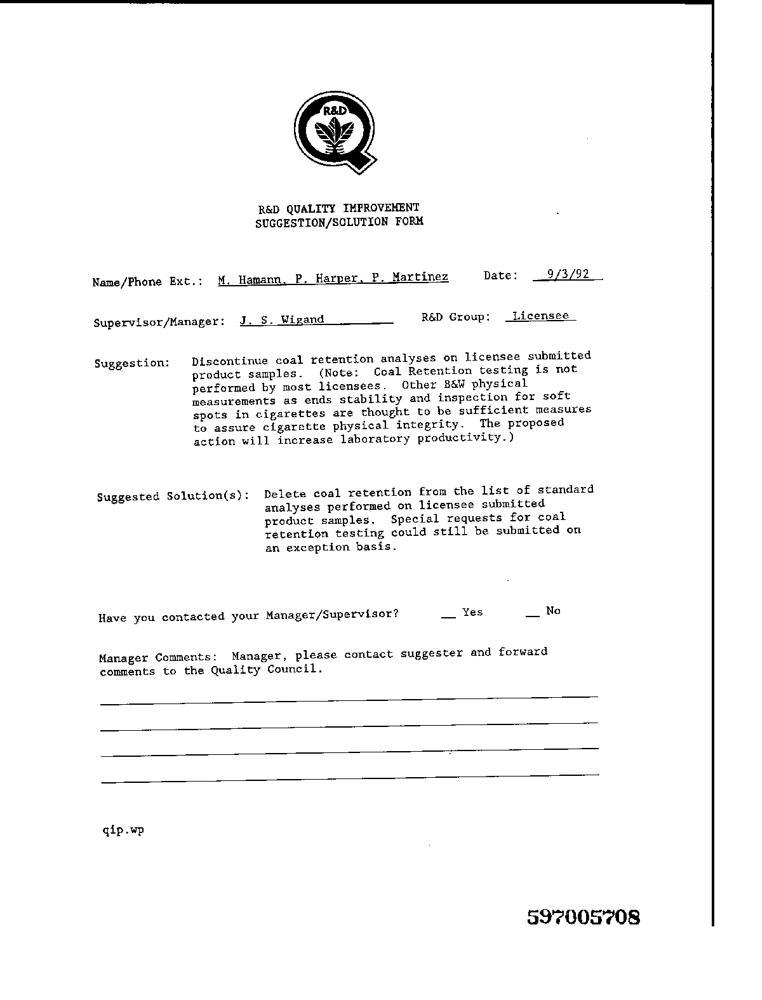

In [12]:
sample = dataset["train"][0]

print("Document ID:", sample["id"])
print("Image size:", sample["image"].size)
print("Words:", len(sample["words"]))
print("Boxes:", len(sample["bboxes"]))
print("Labels:", len(sample["ner_tags"]))

display(sample["image"])

In [13]:
rows = []

for word, box, label_id in zip(
    sample["words"][:30],
    sample["bboxes"][:30],
    sample["ner_tags"][:30],
):
    rows.append({
        "word": word,
        "bbox": box,
        "label_id": label_id,
        "label": id2label[label_id],
    })

sample_df = pd.DataFrame(rows)

display(sample_df)

,word,bbox,label_id,label
0,R&D,"[383, 91, 493, 175]",0,O
1,:,"[287, 316, 295, 327]",3,B-QUESTION
2,Suggestion:,"[124, 355, 221, 370]",3,B-QUESTION
3,Date:,"[632, 268, 679, 282]",3,B-QUESTION
4,Licensee,"[670, 309, 748, 323]",5,B-ANSWER
5,Yes,"[604, 605, 633, 619]",3,B-QUESTION
6,No,"[715, 603, 738, 617]",3,B-QUESTION
7,597005708,"[688, 904, 841, 926]",0,O
8,R&D,"[337, 203, 366, 214]",1,B-HEADER
9,QUALITY,"[374, 203, 438, 216]",2,I-HEADER


In [14]:
all_coordinates = []

for split in dataset.keys():
    for document in dataset[split]:
        for box in document["bboxes"]:
            all_coordinates.extend(box)

coordinates = np.asarray(all_coordinates)

print("Minimum coordinate:", coordinates.min())
print("Maximum coordinate:", coordinates.max())
print("Mean coordinate:", round(float(coordinates.mean()), 2))

assert coordinates.min() >= 0
assert coordinates.max() <= 1000

print("Normalized bounding-box range: PASSED")

Minimum coordinate: 0
Maximum coordinate: 1000
Mean coordinate: 451.33
Normalized bounding-box range: PASSED


In [15]:
image_sizes = []

for split in dataset.keys():
    for document in dataset[split]:
        width, height = document["image"].size

        image_sizes.append({
            "split": split,
            "width": width,
            "height": height,
            "aspect_ratio": width / height,
        })

image_stats = pd.DataFrame(image_sizes)

display(
    image_stats.groupby("split")[
        ["width", "height", "aspect_ratio"]
    ].describe().round(2)
)

width                                                   height          \
       count    mean    std    min    25%    50%    75%    max  count    mean   
split                                                                           
test    50.0  764.20  15.99  754.0  754.0  754.0  771.0  802.0   50.0  1000.0   
train  149.0  768.01  15.60  754.0  762.0  762.0  774.0  863.0  149.0  1000.0   

       ...                 aspect_ratio                                      \
       ...     75%     max        count  mean   std   min   25%   50%   75%   
split  ...                                                                    
test   ...  1000.0  1000.0         50.0  0.76  0.02  0.75  0.75  0.75  0.77   
train  ...  1000.0  1000.0        149.0  0.77  0.02  0.75  0.76  0.76  0.77   

             
        max  
split        
test   0.80  
train  0.86  

[2 rows x 24 columns]

In [16]:
max_length = CONFIG.max_length

length_analysis = stats.copy()

length_analysis["over_model_limit"] = (
    length_analysis["word_count"] > max_length
)

display(
    length_analysis.groupby("split")[
        "over_model_limit"
    ].agg(["sum", "count", "mean"])
)

print("Configured maximum sequence length:", max_length)

,sum,count,mean
split,,,
test,0,50,0.0
train,0,149,0.0


Configured maximum sequence length: 512


Document: 0
ID: 0
Words: 145


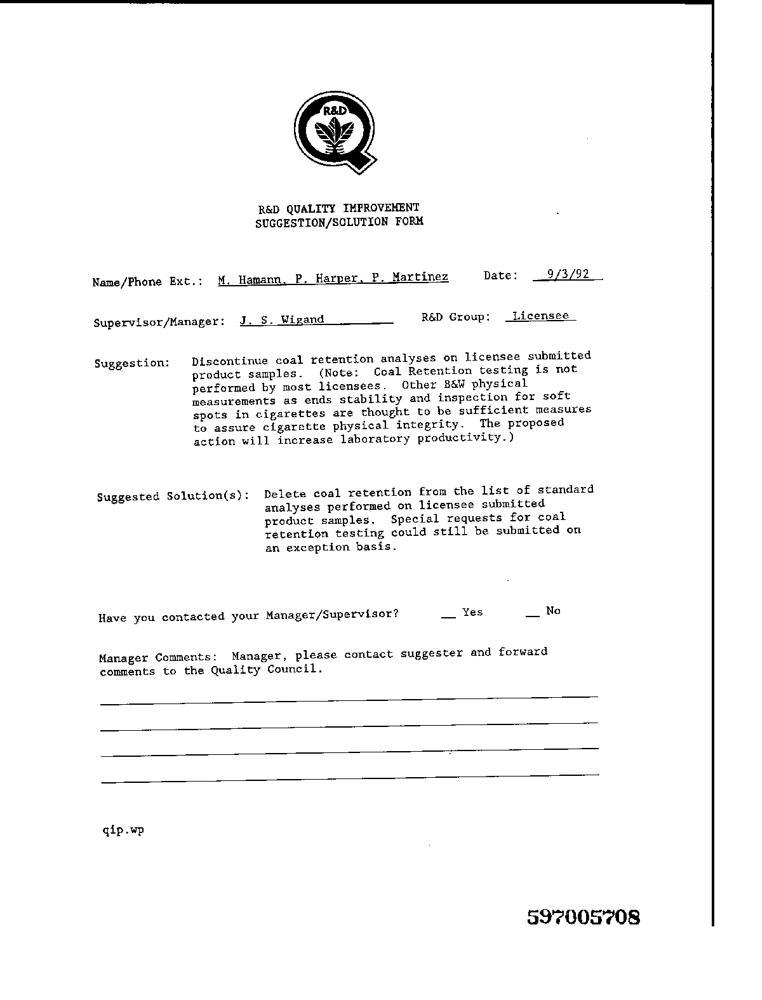

Document: 1
ID: 1
Words: 232


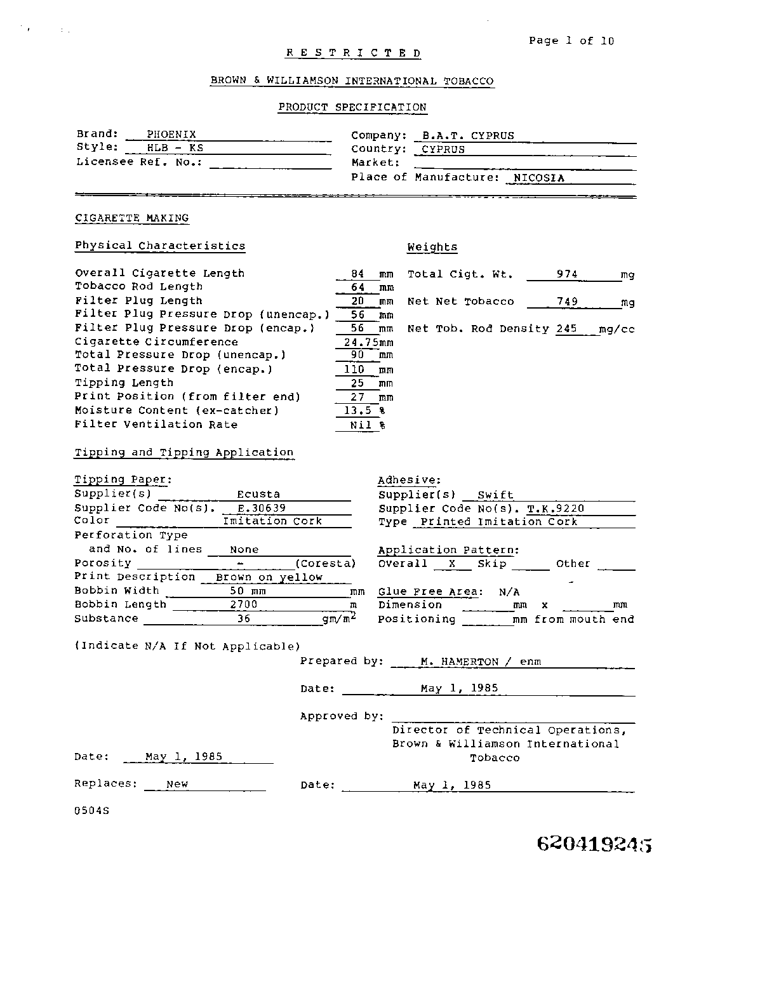

Document: 2
ID: 2
Words: 132


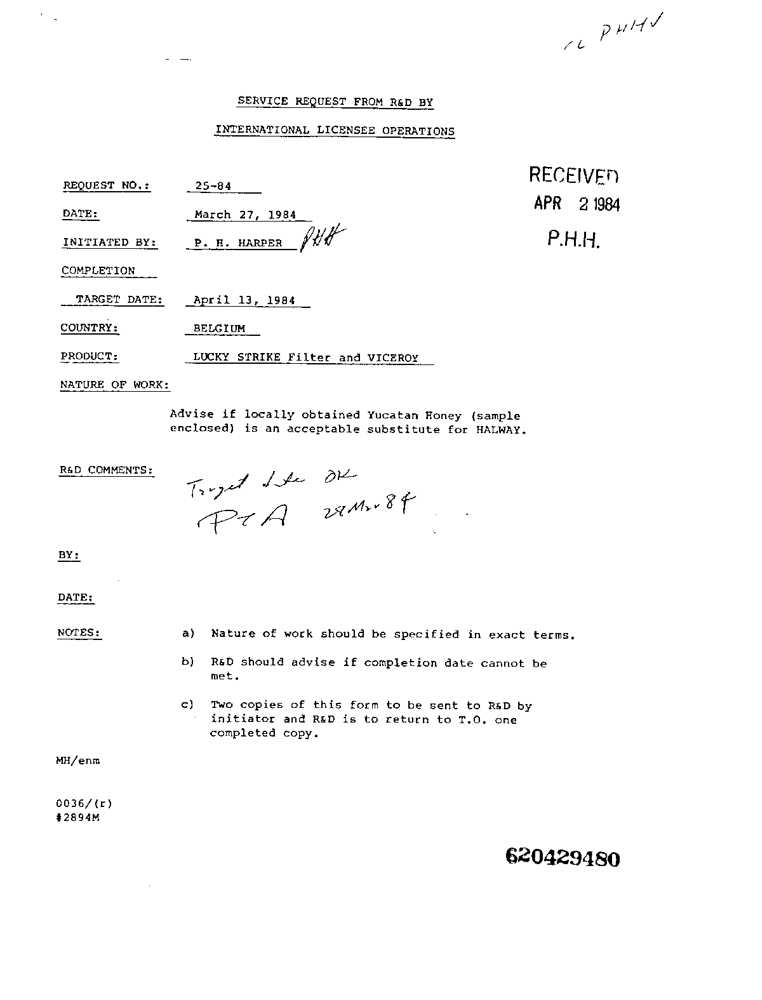

In [17]:
indices = [0, 1, 2]

for index in indices:
    document = dataset["train"][index]

    print("=" * 60)
    print("Document:", index)
    print("ID:", document["id"])
    print("Words:", len(document["words"]))

    display(document["image"])

In [18]:
assert len(dataset["train"]) == 149
assert len(dataset["test"]) == 50

assert len(stats) == (
    len(dataset["train"])
    + len(dataset["test"])
)

for split in dataset.keys():
    for document in dataset[split]:
        assert len(document["words"]) == len(document["bboxes"])
        assert len(document["words"]) == len(document["ner_tags"])

print("Dataset sizes: PASSED")
print("Statistics coverage: PASSED")
print("Annotation alignment: PASSED")
print("EDA integrity checks: PASSED")

Dataset sizes: PASSED
Statistics coverage: PASSED
Annotation alignment: PASSED
EDA integrity checks: PASSED


## Initial Research Observations

This exploratory analysis establishes the empirical properties of the FUNSD dataset used by DocShield AI.

Key aspects investigated include:

- train/test dataset size,
- document-length variation,
- entity-label distribution,
- class imbalance,
- spatial annotation ranges,
- document image dimensions,
- word/box/label alignment,
- and the prevalence of documents that may approach the model's sequence-length constraint.

These observations will guide preprocessing, evaluation, robustness testing, and interpretation of model performance.

Word counts reported here are pre-tokenization statistics. Final LayoutLMv3 sequence lengths may differ because subword tokenization can map one annotated word to multiple tokens.

In [19]:
print("=" * 60)
print("DOCSHIELD AI — FUNSD EDA COMPLETE")
print("=" * 60)

print("Training documents :", len(dataset["train"]))
print("Test documents     :", len(dataset["test"]))
print("Total documents    :", len(stats))
print("Number of labels   :", len(label_list))
print("BBox minimum       :", coordinates.min())
print("BBox maximum       :", coordinates.max())
print("Configured max len :", CONFIG.max_length)

print("=" * 60)
print("Dataset is ready for multimodal preprocessing research.")
print("=" * 60)

DOCSHIELD AI — FUNSD EDA COMPLETE
Training documents : 149
Test documents     : 50
Total documents    : 199
Number of labels   : 7
BBox minimum       : 0
BBox maximum       : 1000
Configured max len : 512
Dataset is ready for multimodal preprocessing research.
